# Compare acoustic simulations

Didgelab supports five different types of acoustic simulations:

* Transmission line modeling (in a Cython and Python implementation).
* 1D Finite Element Analysis
* 2D Finite Element Analysis (axisymmetric)
* 3D Finite Element Analysis (full 3D Helmholtz; the only backend that models bent bores from first principles)

The standard model is the Cython transmission line model because it is by far the fastest.

<Axes: title={'center': 'Bore geometry'}>

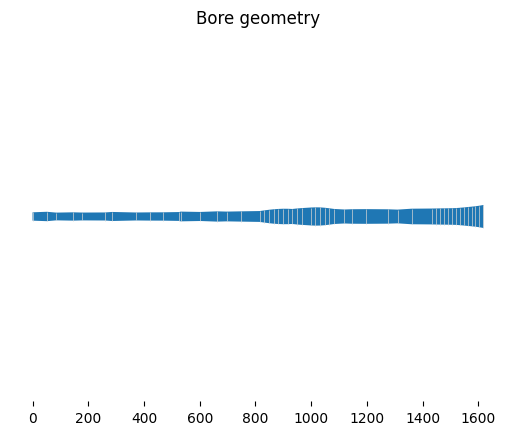

In [1]:
import numpy as np
import sys
sys.path.append("..")

from didgelab import acoustical_simulation, Geo, plot_bore, get_log_simulation_frequencies
import matplotlib.pyplot as plt

geo = [[0.0, 30.0], [51.46899363230762, 33.7784524142553], [85.30423566381049, 27.778931402719003], [146.18854416328128, 29.93556480319699], [179.09381040534882, 28.176128566813905], [259.6802069488814, 28.958055614249236], [285.8190435948692, 32.523925651740726], [371.25522284885295, 28.657844125210218], [419.84135591763703, 29.58434155089998], [466.51643935886017, 29.918981345641743], [527.3904014120826, 31.90101706990902], [531.1184504606866, 34.99886886158793], [602.3168197366772, 32.507540421468754], [662.7828119015719, 36.93351761826125], [696.8927839128953, 35.045862969399295], [746.6898985029628, 36.84736191316634], [815.4460816003736, 39.05244109202236], [832.2110323436855, 43.81877757673142], [848.9759830869973, 48.23024903217608], [865.7409338303091, 51.74295627153961], [882.505884573621, 54.20771815807003], [899.2708353169328, 55.56194698443228], [916.0357860602446, 55.32924009903286], [932.8007368035564, 53.87356959783409], [949.5656875468683, 57.597070298366724], [966.3306382901801, 60.18361651506194], [999.0345487680597, 64.33061402881069], [1015.6645962439811, 65.73163097400256], [1032.2946437199025, 65.17490857100057], [1048.924691195824, 62.75626540369139], [1065.5547386717453, 58.79571998981954], [1082.1847861476667, 54.17039891202623], [1119.7483374925102, 50.13599574849312], [1145.100343149991, 52.07082961850034], [1196.9667987935184, 52.785312404146595], [1275.3325429113545, 51.631734726631564], [1310.4749184562197, 49.258375148257805], [1360.5050929455278, 55.86662095119183], [1432.9324204516163, 57.034846444202294], [1447.2181347373307, 57.6709182777631], [1461.503849023045, 58.180684544167576], [1475.7895633087592, 58.54248286994988], [1490.0752775944734, 58.97267620477503], [1504.3609918801878, 59.524557312640155], [1518.646706165902, 60.26754363477322], [1532.9324204516163, 62.288373855176175], [1547.2181347373307, 64.72655249320907], [1561.503849023045, 67.72346991377412], [1575.7895633087592, 70.39265102058911], [1590.0752775944734, 73.44970066456183], [1604.3609918801878, 77.47427770386149], [1618.646706165902, 82.64877489218449]]
geo = Geo(geo)
plot_bore(geo)

In [ ]:
import pandas as pd
from scipy.signal import argrelmax

simulation_methods = ["tlm_python", "tlm_cython", "1d_fem", "2d_fem", "3d_fem"]
frequencies = get_log_simulation_frequencies(30, 1000, 5)
impedances = []

peaks = pd.DataFrame()

for sm in simulation_methods:
    imp = acoustical_simulation(geo, frequencies, simulation_method=sm) 
    imp /= imp.max()
    impedances.append(imp)
    plt.plot(frequencies, imp, label=sm)

    peaks[sm] = frequencies[argrelmax(imp)]
plt.legend()

peaks.round(2)

In [3]:
# measure the execution times of the different acoustical simulations

import timeit

execution_times = []

def func():
    acoustical_simulation(geo, frequencies, simulation_method=sm)

for sm in simulation_methods:
    execution_time = timeit.timeit(func , number=10)

    execution_times.append({
        "method": sm,
        "time": execution_time
    })

execution_times = pd.DataFrame(execution_times)
execution_times.round(2)

,method,time
0,tlm_python,3.52
1,tlm_cython,0.08
2,1d_fem,5.84
3,2d_fem,35.53
